# PRJNA524206 — EDA và baseline CNV (CNVkit, hg19, 500 kb)

Notebook cho 63 run paired-end (21 bộ ba BCM/TE/BE).

Thứ tự phân tích:
1. Metadata và kiểm tra bộ ba.
2. Kiểm tra FASTQ/BAM và QC căn chỉnh.
3. Chạy/đọc kết quả CNVkit WGS ở bin 500 kb.
4. QC tín hiệu CNV và vẽ profile genome-wide.
5. Đối chiếu từng run với nhãn PGT-A đã công bố.
6. So sánh BCM/TE với BE theo từng phôi.
7. Xuất bảng và hình cho báo cáo.

**Lưu ý:** mỗi phôi có ba nhãn PGT-A riêng cho BCM, TE và BE trong Table II
của Jiao et al. (2019). BE chỉ được dùng làm reference standard khi so sánh
BCM/TE, không phải ground truth lâm sàng độc lập.



In [1]:
from pathlib import Path
import re
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

from IPython.display import display

warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)



## 0. Cấu hình

Chỉ cần sửa `PROJECT_DIR` nếu chuyển project sang vị trí khác.



In [2]:
PROJECT_DIR = Path('/home/vinhvu/genomeCNV/204206')
METADATA_CSV = PROJECT_DIR / 'metadata/SraRunTable.csv'
if not METADATA_CSV.exists():
    METADATA_CSV = PROJECT_DIR / 'SraRunTable.csv'  # tương thích cấu trúc cũ
LABEL_CSV = PROJECT_DIR / 'metadata/PGTA_labels_PRJNA524206.csv'
REF_FASTA = PROJECT_DIR / 'ref_genome/hg19.fa'

FASTQ_DIR = PROJECT_DIR
BAM_DIR = PROJECT_DIR / 'aligned_bam_paired'
QC_DIR = PROJECT_DIR / 'alignment_qc'
# Kết quả chính thức của toàn cohort: 63 run thuộc 21 bộ ba BCM/TE/BE.
# Thư mục cnvkit_baseline_NK12 chỉ còn dùng để lưu pilot lịch sử.
CNVKIT_DIR = PROJECT_DIR / 'cnvkit_500kb'
RESULTS_DIR = PROJECT_DIR / 'eda_results'
FIGURE_DIR = RESULTS_DIR / 'figures'

BIN_SIZE = 500_000
AUTOSOMES = [f'chr{i}' for i in range(1, 23)]
CANONICAL_CHROMS = AUTOSOMES + ['chrX', 'chrY']

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for name, path in {
    'metadata': METADATA_CSV,
    'PGT-A labels': LABEL_CSV,
    'reference': REF_FASTA,
    'BAM directory': BAM_DIR,
    'CNVkit cohort directory': CNVKIT_DIR,
}.items():
    print(f'{name:24s}: {path} | exists={path.exists()}')

metadata                : /home/vinhvu/genomeCNV/204206/metadata/SraRunTable.csv | exists=True
PGT-A labels            : /home/vinhvu/genomeCNV/204206/metadata/PGTA_labels_PRJNA524206.csv | exists=True
reference               : /home/vinhvu/genomeCNV/204206/ref_genome/hg19.fa | exists=True
BAM directory           : /home/vinhvu/genomeCNV/204206/aligned_bam_paired | exists=True
CNVkit cohort directory : /home/vinhvu/genomeCNV/204206/cnvkit_500kb | exists=True


## 1. Phiên bản phần mềm



In [3]:
def tool_version(command):
    exe = shutil.which(command[0])
    if not exe:
        return "NOT FOUND"
    result = subprocess.run(command, capture_output=True, text=True)
    text = (result.stdout or result.stderr).strip().splitlines()
    return text[0] if text else "available"


versions = {
    "python": subprocess.run(
        ["python", "--version"], capture_output=True, text=True
    ).stdout.strip(),
    "samtools": tool_version(["samtools", "--version"]),
    "bwa": tool_version(["bwa"]),
    "cnvkit": tool_version(["cnvkit.py", "version"]),
    "multiqc": tool_version(["multiqc", "--version"]),
}
display(pd.Series(versions, name="version").to_frame())



,version
python,Python 3.10.12
samtools,samtools 1.23.1
bwa,Program: bwa (alignment via Burrows-Wheeler tr...
cnvkit,0.9.13
multiqc,"multiqc, version 1.25.1"


## 2. Metadata: làm sạch và kiểm tra BCM/TE/BE



In [4]:
metadata_raw = pd.read_csv(METADATA_CSV)
print(f"Số dòng: {len(metadata_raw):,}; số cột: {metadata_raw.shape[1]}")
display(metadata_raw.head(3))



Số dòng: 63; số cột: 31


,Run,AGE,Assay Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Consent,DATASTORE filetype,DATASTORE provider,DATASTORE region,Experiment,Instrument,isolate,Library Name,LibraryLayout,LibrarySelection,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,Sample Name,sex,SRA Study,tissue
0,SRR8655356,32,WGA,160,333260640,"IVF Lab of Center of Reproductive Medicine\, D...",PRJNA524206,SAMN11016571,Human,130852953,SHENGJINGYIYUAN,public,"fastq,run.zq,sra","gs,ncbi,s3","gs.us-east1,ncbi.public,s3.us-east-1",SRX5453131,Illumina HiSeq 2500,NK5,M-NK5,PAIRED,Hybrid Selection,GENOMIC,Homo sapiens,ILLUMINA,2020-03-21T00:00:00Z,2019-03-02T01:42:00Z,1,M-NK5,not collected,SRP187297,blastocyst culture medium (BCM) from NK5
1,SRR8655357,32,WGA,160,321637280,"IVF Lab of Center of Reproductive Medicine\, D...",PRJNA524206,SAMN11016578,Human,122687092,SHENGJINGYIYUAN,public,"fastq,run.zq,sra","gs,ncbi,s3","gs.us-east1,ncbi.public,s3.us-east-1",SRX5453130,Illumina HiSeq 2500,NK12,M-NK12,PAIRED,Hybrid Selection,GENOMIC,Homo sapiens,ILLUMINA,2020-03-21T00:00:00Z,2019-03-02T01:42:00Z,1,M-NK12,not collected,SRP187297,blastocyst culture medium (BCM) from NK12
2,SRR8655358,33,WGA,160,102167680,"IVF Lab of Center of Reproductive Medicine\, D...",PRJNA524206,SAMN11016621,Human,36499862,SHENGJINGYIYUAN,public,"fastq,run.zq,sra","gs,ncbi,s3","gs.us-east1,ncbi.public,s3.us-east-1",SRX5453129,Illumina HiSeq 2500,NK14,T-NK14,PAIRED,Hybrid Selection,GENOMIC,Homo sapiens,ILLUMINA,2020-03-21T00:00:00Z,2019-03-02T01:42:00Z,1,T-NK14,not collected,SRP187297,trophectoderm (TE) from NK14


In [5]:
def classify_tissue(value):
    """Phân loại mô bằng cụm từ rõ ràng; tránh điều kiện `or` luôn True."""
    text = str(value).strip().lower()
    if "culture medium" in text or re.search(r"\bbcm\b", text):
        return "BCM"
    if "trophectoderm" in text or re.search(r"\bte\b", text):
        return "TE"
    if "blastocyst-stage embryo" in text or re.search(r"\bbe\b", text):
        return "BE"
    return "UNKNOWN"


required = ["Run", "isolate", "tissue"]
missing = [c for c in required if c not in metadata_raw.columns]
if missing:
    raise KeyError(f"Metadata thiếu cột bắt buộc: {missing}")

preferred = [
    "BioProject", "BioSample", "Experiment", "Run", "isolate",
    "Library Name", "tissue", "LibraryLayout", "Bases", "AvgSpotLen",
]
metadata = metadata_raw[[c for c in preferred if c in metadata_raw.columns]].copy()
metadata["Run"] = metadata["Run"].astype(str).str.strip()
metadata["Embryo_ID"] = metadata["isolate"].astype(str).str.strip()
metadata["Sample_type"] = metadata["tissue"].apply(classify_tissue)

if metadata["Run"].duplicated().any():
    raise ValueError("Có Run bị trùng trong metadata")
if (metadata["Sample_type"] == "UNKNOWN").any():
    display(metadata.loc[metadata["Sample_type"] == "UNKNOWN", ["Run", "tissue"]])
    raise ValueError("Còn mẫu UNKNOWN; cần sửa quy tắc phân loại trước khi tiếp tục")

display(metadata["Sample_type"].value_counts().rename("n_runs").to_frame())



,n_runs
Sample_type,
BCM,21
TE,21
BE,21


In [6]:
trio_counts = metadata.pivot_table(
    index="Embryo_ID", columns="Sample_type", values="Run",
    aggfunc="count", fill_value=0,
)
for tissue in ["BCM", "TE", "BE"]:
    if tissue not in trio_counts:
        trio_counts[tissue] = 0
trio_counts = trio_counts[["BCM", "TE", "BE"]]
trio_counts["Complete_trio"] = trio_counts.eq(1).all(axis=1)

trio_map = metadata.pivot_table(
    index="Embryo_ID", columns="Sample_type", values="Run", aggfunc="first"
).reset_index()
trio_map = trio_map.merge(
    trio_counts["Complete_trio"].reset_index(), on="Embryo_ID", how="left"
)

print(f"Runs: {len(metadata)}")
print(f"Phôi: {metadata['Embryo_ID'].nunique()}")
print(f"Bộ ba hoàn chỉnh: {int(trio_counts['Complete_trio'].sum())}")
display(trio_counts)

metadata.to_csv(RESULTS_DIR / "metadata_clean.csv", index=False)
trio_map.to_csv(RESULTS_DIR / "trio_map.csv", index=False)



Runs: 63
Phôi: 21
Bộ ba hoàn chỉnh: 21


Sample_type,BCM,TE,BE,Complete_trio
Embryo_ID,,,,
NK1,1,1,1,True
NK10,1,1,1,True
NK11,1,1,1,True
NK12,1,1,1,True
NK13,1,1,1,True
NK14,1,1,1,True
NK15,1,1,1,True
NK16,1,1,1,True
NK17,1,1,1,True


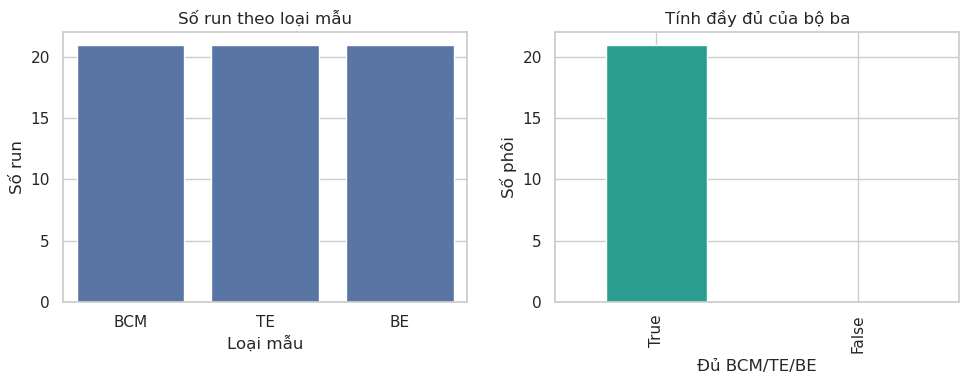

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=metadata, x="Sample_type", order=["BCM", "TE", "BE"], ax=axes[0])
axes[0].set(title="Số run theo loại mẫu", xlabel="Loại mẫu", ylabel="Số run")
trio_counts["Complete_trio"].value_counts().reindex([True, False], fill_value=0).plot.bar(
    ax=axes[1], color=["#2a9d8f", "#e76f51"]
)
axes[1].set(title="Tính đầy đủ của bộ ba", xlabel="Đủ BCM/TE/BE", ylabel="Số phôi")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_metadata_overview.png", dpi=180, bbox_inches="tight")
plt.show()



## 3. Manifest FASTQ/BAM

Mỗi Run phải có đúng một R1, một R2 và sau alignment có một BAM cuối cùng.



In [8]:
def final_bam_for(run):
    candidates = [
        BAM_DIR / f"{run}.filtered.sorted.bam",
        BAM_DIR / f"{run}.marked.filtered.sorted.bam",
        BAM_DIR / f"{run}.sorted.bam",
    ]
    return next((p for p in candidates if p.exists()), candidates[0])


manifest = metadata[["Embryo_ID", "Sample_type", "Run"]].copy()
manifest["R1"] = manifest["Run"].map(lambda x: FASTQ_DIR / f"{x}_1.fastq")
manifest["R2"] = manifest["Run"].map(lambda x: FASTQ_DIR / f"{x}_2.fastq")
manifest["BAM"] = manifest["Run"].map(final_bam_for)
manifest["R1_exists"] = manifest["R1"].map(Path.exists)
manifest["R2_exists"] = manifest["R2"].map(Path.exists)
manifest["BAM_exists"] = manifest["BAM"].map(Path.exists)
manifest["BAI_exists"] = manifest["BAM"].map(
    lambda p: Path(str(p) + ".bai").exists() or p.with_suffix(".bai").exists()
)

summary = manifest[["R1_exists", "R2_exists", "BAM_exists", "BAI_exists"]].sum()
display(summary.rename("available").to_frame().assign(expected=len(manifest)))

incomplete_files = manifest.loc[
    ~manifest[["R1_exists", "R2_exists", "BAM_exists", "BAI_exists"]].all(axis=1)
]
if len(incomplete_files):
    print("Các run chưa hoàn chỉnh:")
    display(incomplete_files[[
        "Run", "Sample_type", "R1_exists", "R2_exists", "BAM_exists", "BAI_exists"
    ]])
else:
    print("PASS: toàn bộ run có đủ FASTQ, BAM và BAM index.")

manifest.assign(
    R1=manifest["R1"].astype(str), R2=manifest["R2"].astype(str),
    BAM=manifest["BAM"].astype(str),
).to_csv(RESULTS_DIR / "file_manifest.csv", index=False)



,available,expected
R1_exists,63,63
R2_exists,63,63
BAM_exists,63,63
BAI_exists,63,63


PASS: toàn bộ run có đủ FASTQ, BAM và BAM index.


## 4. QC BAM

Cell này đọc các file `samtools flagstat` đã tạo trong `alignment_qc`. Nó hỗ trợ
cả tên `RUN.filtered.flagstat.txt` và các biến thể có chứa Run + `flagstat`.



In [9]:
def find_qc_file(run, keyword):
    matches = sorted(QC_DIR.glob(f"{run}*{keyword}*")) if QC_DIR.exists() else []
    if not matches:
        return None
    # Ưu tiên BAM marked/trước lọc để duplicate rate không bị thành 0 do -F 1024.
    prefilter = [p for p in matches if "filtered" not in p.name.lower()]
    return prefilter[0] if prefilter else matches[0]


def parse_flagstat(path):
    values = {}
    if path is None:
        return values
    text = path.read_text(errors="replace")
    patterns = {
        "total_reads": r"^(\d+) \+ \d+ in total",
        "mapped_reads": r"^(\d+) \+ \d+ mapped \(",
        "properly_paired_reads": r"^(\d+) \+ \d+ properly paired \(",
        "duplicate_reads": r"^(\d+) \+ \d+ duplicates",
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, text, flags=re.MULTILINE)
        values[key] = int(match.group(1)) if match else np.nan
    total = values.get("total_reads", np.nan)
    if pd.notna(total) and total > 0:
        values["mapped_pct"] = 100 * values["mapped_reads"] / total
        values["properly_paired_pct"] = 100 * values["properly_paired_reads"] / total
        values["duplicate_pct"] = 100 * values["duplicate_reads"] / total
    values["flagstat_file"] = str(path)
    return values


qc_rows = []
for row in manifest.itertuples(index=False):
    qc = parse_flagstat(find_qc_file(row.Run, "flagstat"))
    qc.update({"Run": row.Run, "Embryo_ID": row.Embryo_ID, "Sample_type": row.Sample_type})
    qc_rows.append(qc)

qc = pd.DataFrame(qc_rows)
qc.to_csv(RESULTS_DIR / "alignment_qc_summary.csv", index=False)
display(qc.head())



,total_reads,mapped_reads,properly_paired_reads,duplicate_reads,mapped_pct,properly_paired_pct,duplicate_pct,flagstat_file,Run,Embryo_ID,Sample_type
0,4174082,3971865,3837386,703032,95.155414,91.933652,16.842793,/home/vinhvu/genomeCNV/204206/alignment_qc/SRR...,SRR8655356,NK5,BCM
1,4027377,3949015,3850456,502966,98.054267,95.607042,12.488674,/home/vinhvu/genomeCNV/204206/alignment_qc/SRR...,SRR8655357,NK12,BCM
2,1278949,1260322,1228604,64498,98.543570,96.063565,5.043047,/home/vinhvu/genomeCNV/204206/alignment_qc/SRR...,SRR8655358,NK14,TE
3,1052166,1030090,990218,44541,97.901852,94.112336,4.233267,/home/vinhvu/genomeCNV/204206/alignment_qc/SRR...,SRR8655359,NK12,TE
4,659778,649474,632254,27937,98.438263,95.828294,4.234303,/home/vinhvu/genomeCNV/204206/alignment_qc/SRR...,SRR8655360,NK12,BE


/tmp/ipykernel_2966960/438615133.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


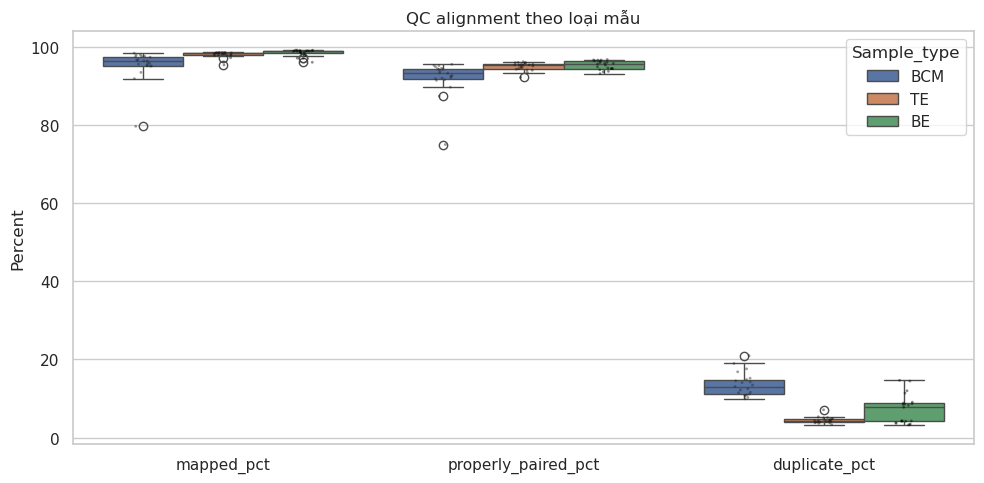

In [10]:
metric_cols = [c for c in ["mapped_pct", "properly_paired_pct", "duplicate_pct"] if c in qc]
if metric_cols and qc[metric_cols].notna().any().any():
    qc_long = qc.melt(
        id_vars=["Run", "Sample_type"], value_vars=metric_cols,
        var_name="Metric", value_name="Percent",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=qc_long, x="Metric", y="Percent", hue="Sample_type")
    sns.stripplot(
        data=qc_long, x="Metric", y="Percent", hue="Sample_type",
        dodge=True, color="black", size=2, alpha=.45, legend=False,
    )
    plt.title("QC alignment theo loại mẫu")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "02_alignment_qc.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Chưa có file flagstat phù hợp trong", QC_DIR)



## 5. Chạy CNVkit WGS 500 kb (chỉ bật khi 63 BAM đã PASS)

Tất cả mẫu dùng **cùng một flat reference** và cùng bin 500 kb. Cell mặc định
không chạy để tránh vô tình khởi động job dài. Đổi `RUN_CNVKIT = True` khi manifest
đã đủ 63 BAM. Nên chạy notebook trong `tmux` hoặc chạy lệnh tương đương ở terminal.



In [11]:
RUN_CNVKIT = False

valid_bams = manifest.loc[manifest["BAM_exists"], "BAM"].astype(str).tolist()
CNVKIT_DIR.mkdir(parents=True, exist_ok=True)
flat_reference = CNVKIT_DIR / "hg19_flat_500kb.cnn"

cnvkit_command = [
    "cnvkit.py", "batch", *valid_bams,
    "-n",
    "--method", "wgs",
    "--fasta", str(REF_FASTA),
    "--target-avg-size", str(BIN_SIZE),
    "--count-reads",
    "--drop-low-coverage",
    "--output-reference", str(flat_reference),
    "--output-dir", str(CNVKIT_DIR),
    "--processes", "2",
]

print(" ".join(cnvkit_command[:8]), "...", f"({len(valid_bams)} BAMs)")
if RUN_CNVKIT:
    if len(valid_bams) != len(manifest):
        raise RuntimeError(f"Chỉ có {len(valid_bams)}/{len(manifest)} BAM; chưa chạy CNVkit")
    log_path = CNVKIT_DIR / "cnvkit_batch.log"
    with log_path.open("w") as log:
        subprocess.run(cnvkit_command, stdout=log, stderr=subprocess.STDOUT, check=True)
    print("CNVkit hoàn tất:", log_path)
else:
    print("RUN_CNVKIT=False — chỉ chuẩn bị lệnh, chưa chạy.")



cnvkit.py batch /home/vinhvu/genomeCNV/204206/aligned_bam_paired/SRR8655356.filtered.sorted.bam /home/vinhvu/genomeCNV/204206/aligned_bam_paired/SRR8655357.filtered.sorted.bam /home/vinhvu/genomeCNV/204206/aligned_bam_paired/SRR8655358.filtered.sorted.bam /home/vinhvu/genomeCNV/204206/aligned_bam_paired/SRR8655359.filtered.sorted.bam /home/vinhvu/genomeCNV/204206/aligned_bam_paired/SRR8655360.filtered.sorted.bam /home/vinhvu/genomeCNV/204206/aligned_bam_paired/SRR8655361.filtered.sorted.bam ... (63 BAMs)
RUN_CNVKIT=False — chỉ chuẩn bị lệnh, chưa chạy.


## 6. Đọc `.cnr/.cns` và QC tín hiệu CNV

- `.cnr`: tín hiệu log₂ ở từng bin 500 kb.
- `.cns`: các bin được CBS gộp thành những vùng liên tiếp có mức log₂ tương tự.
- `n_cbs_segments`: tổng số vùng CBS trong một mẫu, bao gồm cả vùng neutral; **không phải số CNV**.
- MAD/IQR log₂ phản ánh độ phân tán tín hiệu. Số segment cao chỉ gợi ý genome bị chia nhỏ hơn và phải được đọc cùng MAD, độ sâu và false positive.


In [12]:
def locate_cnv_file(run, suffix):
    # Chỉ chấp nhận output lõi RUN.filtered.sorted.cnr/cns.
    # Không fallback sang .call.cns hoặc .bintest.cns.
    exact = CNVKIT_DIR / f'{run}.filtered.sorted.{suffix}'
    return exact if exact.is_file() and exact.stat().st_size > 0 else None


cnv_files = metadata[['Run', 'Embryo_ID', 'Sample_type']].copy()
cnv_files['CNR'] = cnv_files['Run'].map(lambda x: locate_cnv_file(x, 'cnr'))
cnv_files['CNS'] = cnv_files['Run'].map(lambda x: locate_cnv_file(x, 'cns'))
cnv_files['CNR_exists'] = cnv_files['CNR'].map(lambda p: p is not None)
cnv_files['CNS_exists'] = cnv_files['CNS'].map(lambda p: p is not None)

n_cnr = int(cnv_files['CNR_exists'].sum())
n_cns = int(cnv_files['CNS_exists'].sum())
print('CNR:', n_cnr, '/', len(cnv_files))
print('CNS:', n_cns, '/', len(cnv_files))

if n_cnr != 63 or n_cns != 63:
    missing_cnv = cnv_files.loc[
        ~(cnv_files['CNR_exists'] & cnv_files['CNS_exists']),
        ['Run', 'Embryo_ID', 'Sample_type', 'CNR_exists', 'CNS_exists'],
    ]
    display(missing_cnv)
    raise RuntimeError(f'Cần đủ 63 CNR và 63 CNS lõi; hiện có CNR={n_cnr}, CNS={n_cns}')

print('PASS: đủ 63 CNR và 63 CNS lõi; không dùng nhầm call/bintest CNS.')

CNR: 63 / 63
CNS: 63 / 63
PASS: đủ 63 CNR và 63 CNS lõi; không dùng nhầm call/bintest CNS.


In [13]:
def robust_mad(values):
    values = np.asarray(values, dtype=float)
    med = np.nanmedian(values)
    return np.nanmedian(np.abs(values - med))


cnv_qc_rows = []
for row in cnv_files.loc[cnv_files["CNR_exists"]].itertuples(index=False):
    cnr = pd.read_csv(row.CNR, sep="	")
    canonical = cnr[cnr["chromosome"].isin(CANONICAL_CHROMS)].copy()
    auto = canonical[canonical["chromosome"].isin(AUTOSOMES)]
    cns = pd.read_csv(row.CNS, sep="	") if row.CNS is not None else pd.DataFrame()
    cnv_qc_rows.append({
        "Run": row.Run,
        "Embryo_ID": row.Embryo_ID,
        "Sample_type": row.Sample_type,
        "n_bins": len(canonical),
        "autosome_median_log2": auto["log2"].median(),
        "autosome_mad_log2": robust_mad(auto["log2"]),
        "autosome_iqr_log2": auto["log2"].quantile(.75) - auto["log2"].quantile(.25),
        "n_cbs_segments": len(cns),  # gồm cả neutral; không phải số CNV
    })

cnv_qc = pd.DataFrame(cnv_qc_rows)
cnv_qc.to_csv(RESULTS_DIR / "cnv_signal_qc.csv", index=False)
display(cnv_qc.sort_values("autosome_mad_log2", ascending=False).head(10))

,Run,Embryo_ID,Sample_type,n_bins,autosome_median_log2,autosome_mad_log2,autosome_iqr_log2,n_cbs_segments
23,SRR8655379,NK2,BE,5780,0.001201,0.247360,0.506090,44
51,SRR8655407,NK10,BE,5780,0.000000,0.232428,0.465876,44
35,SRR8655391,NK1,BE,5780,-0.012737,0.226306,0.466108,46
10,SRR8655366,NK11,BE,5780,-0.005441,0.225186,0.452113,44
8,SRR8655364,NK8,TE,5780,-0.018863,0.223233,0.453124,45
5,SRR8655361,NK8,BE,5780,-0.006454,0.218322,0.442336,44
17,SRR8655373,NK17,TE,5780,-0.006032,0.205238,0.418198,45
28,SRR8655384,NK19,BE,5780,0.001474,0.203617,0.408482,44
54,SRR8655410,NK9,BE,5780,0.006196,0.201288,0.402579,46
31,SRR8655387,NK13,TE,5780,-0.026526,0.200059,0.398835,47


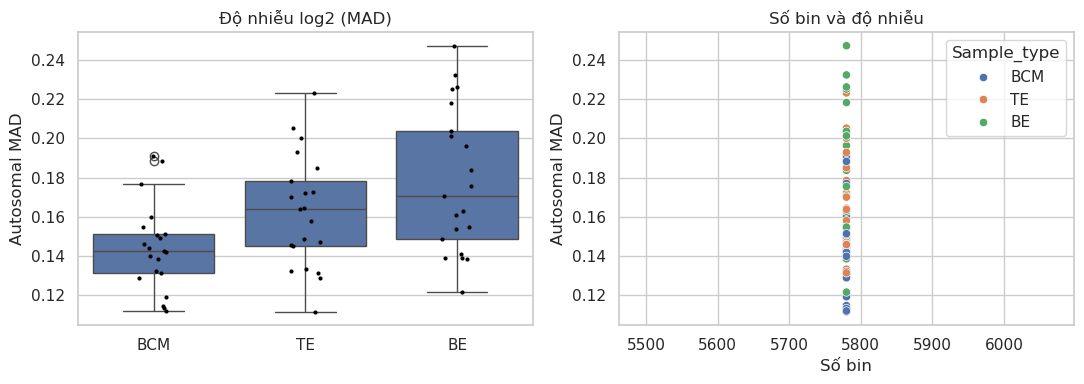

In [14]:
if len(cnv_qc):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.boxplot(data=cnv_qc, x="Sample_type", y="autosome_mad_log2", ax=axes[0])
    sns.stripplot(data=cnv_qc, x="Sample_type", y="autosome_mad_log2", color="black", size=3, ax=axes[0])
    axes[0].set(title="Độ nhiễu log2 (MAD)", xlabel="", ylabel="Autosomal MAD")
    sns.scatterplot(
        data=cnv_qc, x="n_bins", y="autosome_mad_log2",
        hue="Sample_type", ax=axes[1],
    )
    axes[1].set(title="Số bin và độ nhiễu", xlabel="Số bin", ylabel="Autosomal MAD")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "03_cnv_signal_qc.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Chưa có CNR; chạy phần CNVkit trước.")



## 7. Hàm vẽ profile genome-wide

Điểm: log2 ratio theo bin. Đường đỏ: segment từ `.cns`.



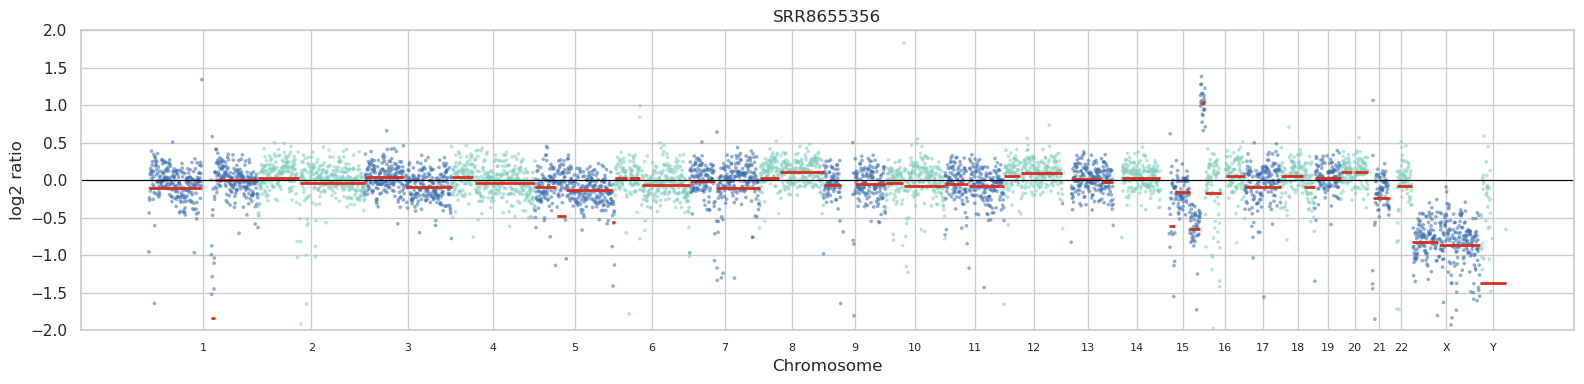

In [15]:
chrom_order = {chrom: i for i, chrom in enumerate(CANONICAL_CHROMS)}


def prepare_genome_coordinates(cnr, cns=None):
    cnr = cnr[cnr["chromosome"].isin(CANONICAL_CHROMS)].copy()
    cnr["_order"] = cnr["chromosome"].map(chrom_order)
    cnr = cnr.sort_values(["_order", "start"])
    chrom_sizes = cnr.groupby("chromosome", sort=False)["end"].max()
    offsets, cursor = {}, 0
    for chrom in chrom_sizes.index:
        offsets[chrom] = cursor
        cursor += chrom_sizes[chrom]
    cnr["genome_x"] = cnr["start"] + cnr["chromosome"].map(offsets)
    centers = {
        chrom: offsets[chrom] + size / 2 for chrom, size in chrom_sizes.items()
    }
    if cns is not None and len(cns):
        cns = cns[cns["chromosome"].isin(offsets)].copy()
        cns["x_start"] = cns["start"] + cns["chromosome"].map(offsets)
        cns["x_end"] = cns["end"] + cns["chromosome"].map(offsets)
    return cnr, cns, centers, offsets


def plot_profile(run, ax=None, ylim=(-2, 2), title=None):
    cnr_path = locate_cnv_file(run, "cnr")
    cns_path = locate_cnv_file(run, "cns")
    if cnr_path is None:
        raise FileNotFoundError(f"Không tìm thấy CNR cho {run}")
    cnr = pd.read_csv(cnr_path, sep="\t")
    cns = pd.read_csv(cns_path, sep="\t") if cns_path else pd.DataFrame()
    cnr, cns, centers, offsets = prepare_genome_coordinates(cnr, cns)
    if ax is None:
        _, ax = plt.subplots(figsize=(16, 4))
    colors = cnr["_order"].map(lambda x: "#386cb0" if x % 2 == 0 else "#7fcdbb")
    ax.scatter(cnr["genome_x"], cnr["log2"], c=colors, s=7, alpha=.55, linewidths=0)
    if cns is not None and len(cns):
        for seg in cns.itertuples(index=False):
            ax.hlines(seg.log2, seg.x_start, seg.x_end, color="#d7301f", linewidth=2)
    ax.axhline(0, color="black", linewidth=.8)
    ax.set_xticks(list(centers.values()))
    ax.set_xticklabels([c.replace("chr", "") for c in centers], fontsize=8)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Chromosome")
    ax.set_ylabel("log2 ratio")
    ax.set_title(title or run)
    return ax


available_runs = cnv_files.loc[cnv_files["CNR_exists"], "Run"].tolist()
if available_runs:
    SELECTED_RUN = available_runs[0]
    fig, ax = plt.subplots(figsize=(16, 4))
    plot_profile(SELECTED_RUN, ax=ax)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"04_profile_{SELECTED_RUN}.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Chưa có run để vẽ profile.")



In [16]:
# Bật cờ này nếu muốn xuất một PDF nhiều trang chứa profile của toàn bộ run.
EXPORT_ALL_PROFILES = False
all_profiles_pdf = RESULTS_DIR / "all_genomewide_profiles.pdf"

if EXPORT_ALL_PROFILES and available_runs:
    with PdfPages(all_profiles_pdf) as pdf:
        for run in available_runs:
            fig, ax = plt.subplots(figsize=(16, 4))
            plot_profile(run, ax=ax)
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    print("Đã xuất:", all_profiles_pdf)
else:
    print("EXPORT_ALL_PROFILES=False — chưa xuất PDF toàn bộ profile.")



EXPORT_ALL_PROFILES=False — chưa xuất PDF toàn bộ profile.


## 8. Profile bộ ba BCM/TE/BE



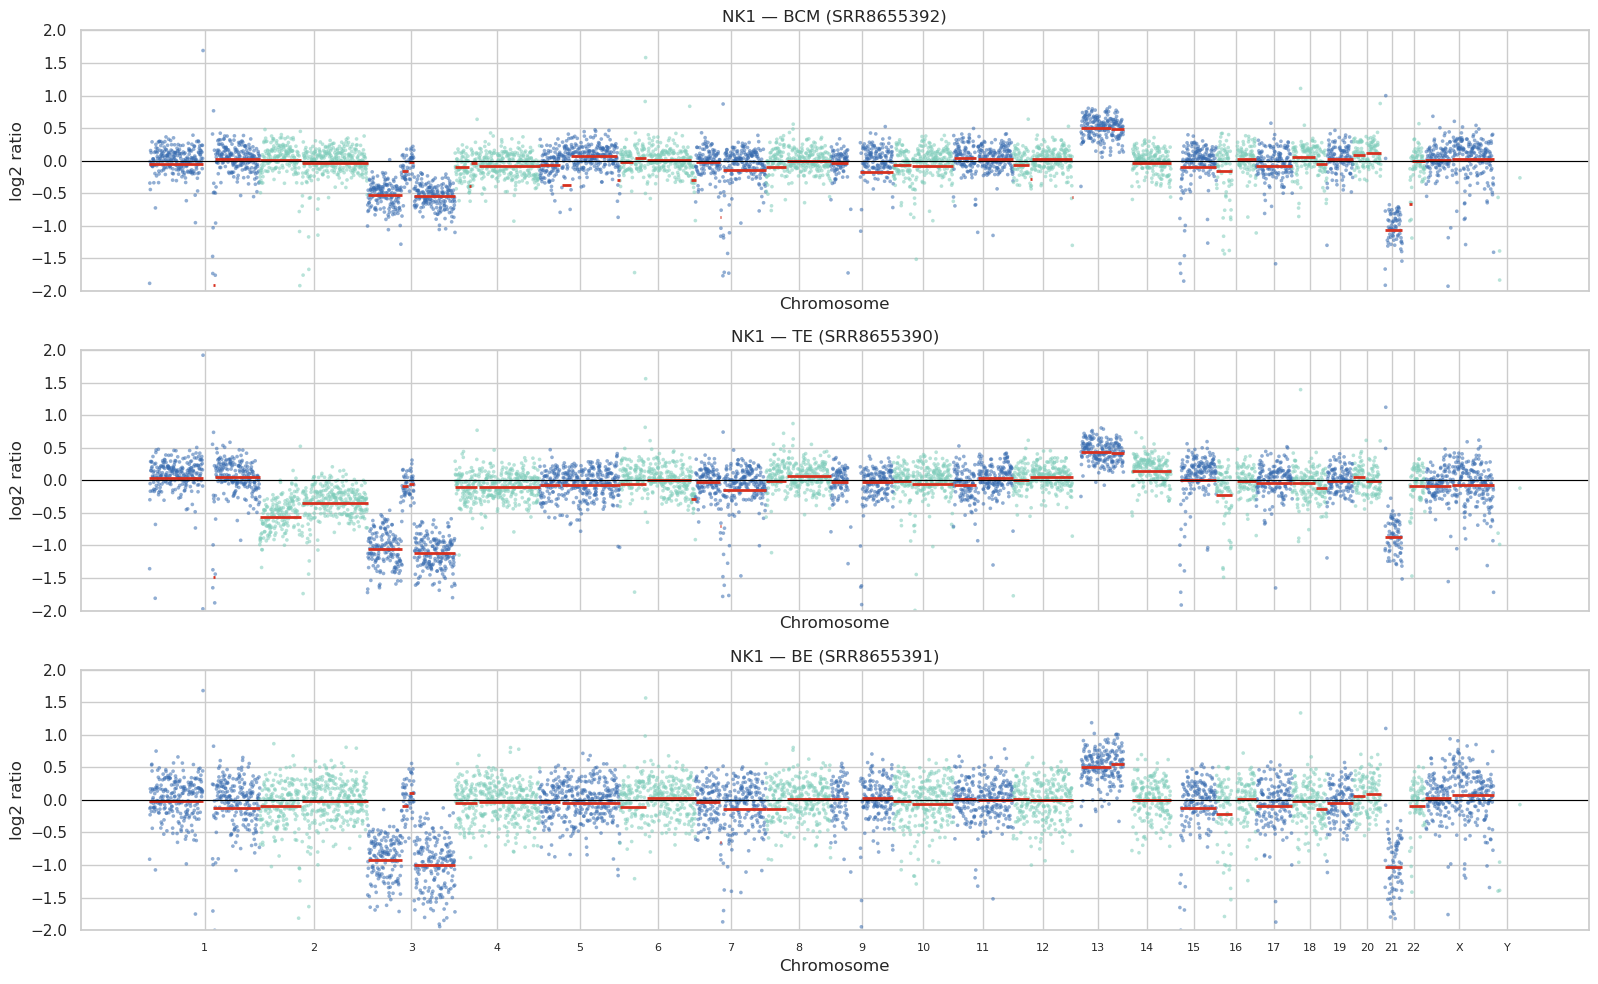

In [17]:
available_cnr_runs = set(cnv_files.loc[cnv_files["CNR_exists"], "Run"])
available_trios = trio_map.loc[
    trio_map["Complete_trio"]
    & trio_map[["BCM", "TE", "BE"]].apply(
        lambda row: all(run in available_cnr_runs for run in row), axis=1
    )
].copy()

if len(available_trios):
    SELECTED_EMBRYO = available_trios.iloc[0]["Embryo_ID"]
    selected = trio_map.set_index("Embryo_ID").loc[SELECTED_EMBRYO]
    if all(locate_cnv_file(selected[t], "cnr") is not None for t in ["BCM", "TE", "BE"]):
        fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True, sharey=True)
        for ax, tissue in zip(axes, ["BCM", "TE", "BE"]):
            plot_profile(selected[tissue], ax=ax, title=f"{SELECTED_EMBRYO} — {tissue} ({selected[tissue]})")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"05_trio_profile_{SELECTED_EMBRYO}.png", dpi=180, bbox_inches="tight")
        plt.show()
    else:
        print(f"{SELECTED_EMBRYO} chưa đủ ba file CNR.")
else:
    print("Chưa có bộ ba nào đủ cả ba file CNR để vẽ profile.")



## 9. Ma trận log₂ và đồng thuận chromosome-level thăm dò

Mỗi chromosome được tóm tắt bằng median log₂ của các bin, với ngưỡng loss `< -0.25`, neutral `[-0.25, 0.20]` và gain `> 0.20`.

Phần này chỉ dùng để nhìn cấu trúc tín hiệu ở độ phân giải toàn chromosome. Các ngưỡng là quy ước EDA, không phải CNVkit call và không dùng làm kết quả hiệu năng chính. Kết luận baseline chính nằm ở phần bin-level sử dụng CBS call.


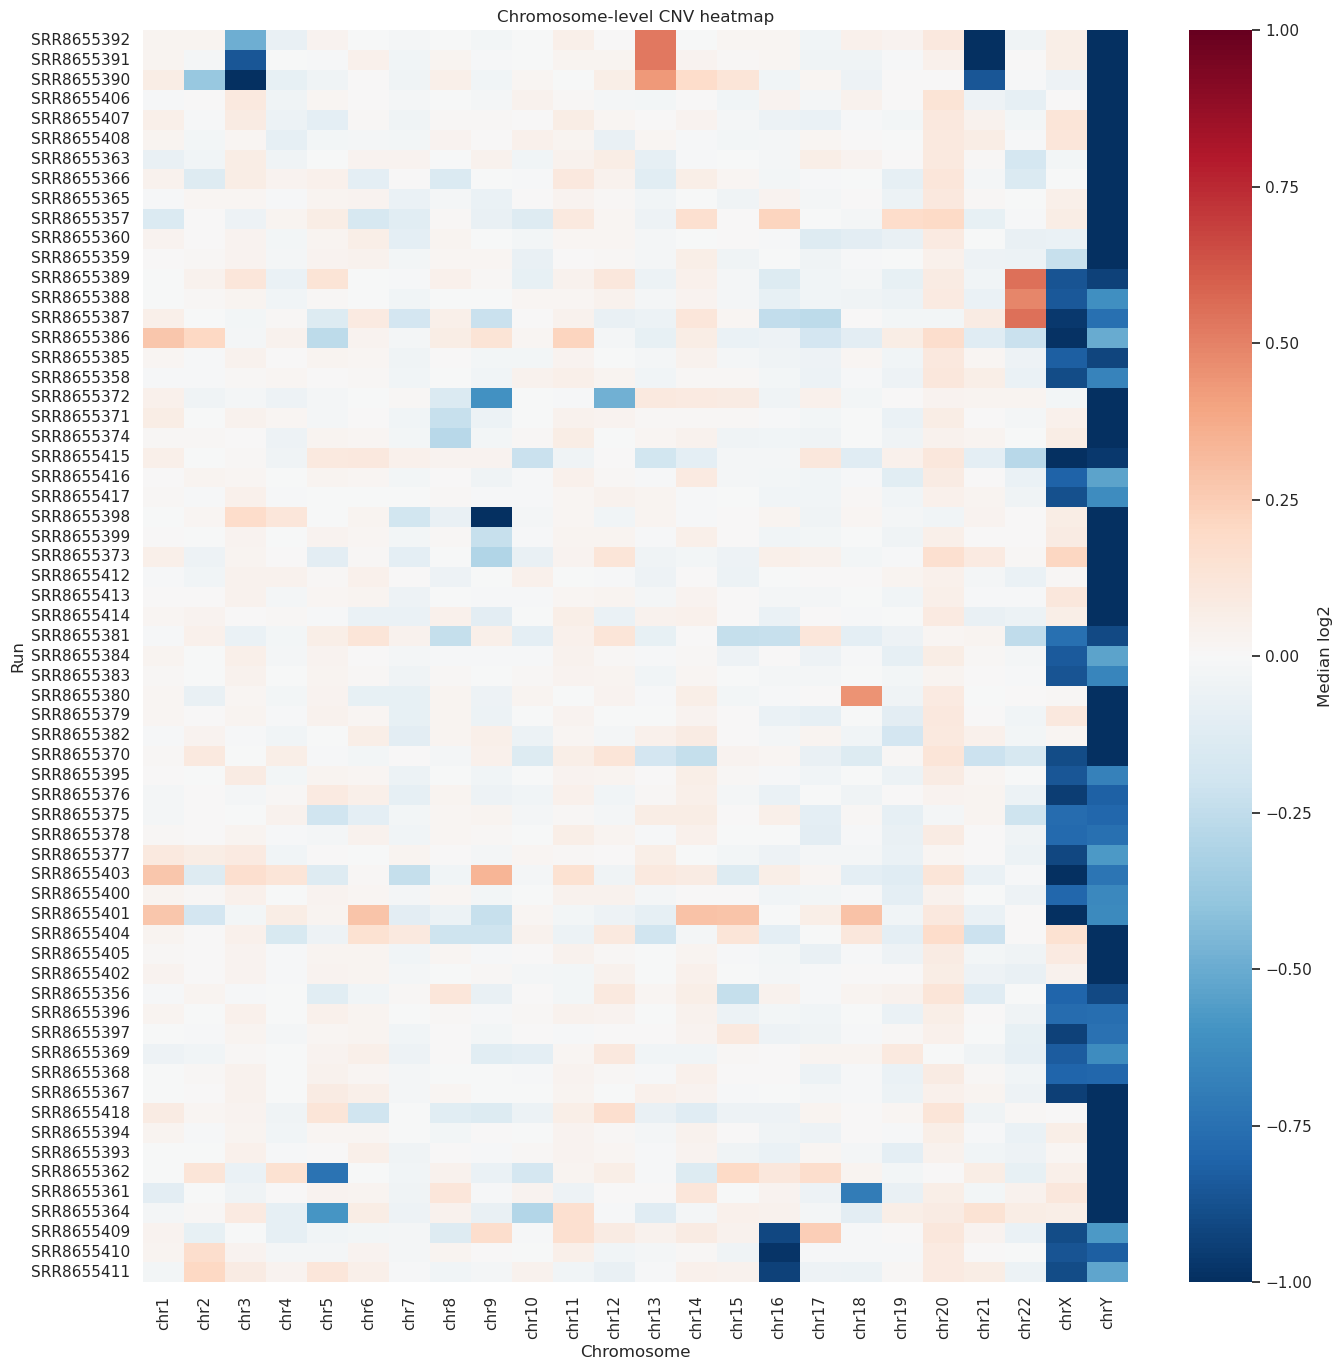

In [18]:
chrom_rows = []
for row in cnv_files.loc[cnv_files["CNR_exists"]].itertuples(index=False):
    cnr = pd.read_csv(row.CNR, sep="\t")
    values = (
        cnr[cnr["chromosome"].isin(CANONICAL_CHROMS)]
        .groupby("chromosome")["log2"].median()
    )
    for chrom, log2_value in values.items():
        chrom_rows.append({
            "Run": row.Run, "Embryo_ID": row.Embryo_ID,
            "Sample_type": row.Sample_type, "chromosome": chrom,
            "median_log2": log2_value,
        })

chromosome_log2 = pd.DataFrame(chrom_rows)
chromosome_log2.to_csv(RESULTS_DIR / "chromosome_median_log2.tsv", sep="\t", index=False)

if len(chromosome_log2):
    matrix = chromosome_log2.pivot(index="Run", columns="chromosome", values="median_log2")
    matrix = matrix.reindex(columns=CANONICAL_CHROMS)
    order = metadata.sort_values(["Embryo_ID", "Sample_type"])["Run"]
    matrix = matrix.reindex([r for r in order if r in matrix.index])
    plt.figure(figsize=(14, max(6, .22 * len(matrix))))
    sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-1, vmax=1, cbar_kws={"label": "Median log2"})
    plt.title("Chromosome-level CNV heatmap")
    plt.xlabel("Chromosome")
    plt.ylabel("Run")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "06_chromosome_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Chưa có dữ liệu để tạo heatmap.")



In [19]:
LOSS_THRESHOLD = -0.25
GAIN_THRESHOLD = 0.20


def state_from_log2(x):
    if pd.isna(x):
        return np.nan
    if x < LOSS_THRESHOLD:
        return "LOSS"
    if x > GAIN_THRESHOLD:
        return "GAIN"
    return "NEUTRAL"


agreement_rows = []
if len(chromosome_log2):
    auto = chromosome_log2[chromosome_log2["chromosome"].isin(AUTOSOMES)].copy()
    auto["state"] = auto["median_log2"].apply(state_from_log2)
    states = auto.pivot_table(
        index=["Embryo_ID", "chromosome"], columns="Sample_type",
        values="state", aggfunc="first",
    ).reset_index()
    for test_tissue in ["BCM", "TE"]:
        if test_tissue not in states or "BE" not in states:
            continue
        paired = states.dropna(subset=[test_tissue, "BE"])
        for embryo, group in paired.groupby("Embryo_ID"):
            y_true = group["BE"] != "NEUTRAL"
            y_pred = group[test_tissue] != "NEUTRAL"
            tp = int((y_true & y_pred).sum())
            tn = int((~y_true & ~y_pred).sum())
            fp = int((~y_true & y_pred).sum())
            fn = int((y_true & ~y_pred).sum())
            agreement_rows.append({
                "Embryo_ID": embryo, "Test_sample": test_tissue,
                "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
                "Specificity": tn / (tn + fp) if tn + fp else np.nan,
                "Precision": tp / (tp + fp) if tp + fp else np.nan,
                "Accuracy": (tp + tn) / len(group) if len(group) else np.nan,
            })

agreement = pd.DataFrame(agreement_rows)
agreement.to_csv(RESULTS_DIR / "exploratory_chromosome_agreement.tsv", sep="	", index=False)
display(agreement)

,Embryo_ID,Test_sample,TP,TN,FP,FN,Sensitivity,Specificity,Precision,Accuracy
0,NK1,BCM,3,19,0,0,1.0,1.000000,1.00,1.000000
1,NK10,BCM,0,22,0,0,NaN,1.000000,NaN,1.000000
2,NK11,BCM,0,22,0,0,NaN,1.000000,NaN,1.000000
3,NK12,BCM,0,20,2,0,NaN,0.909091,0.00,0.909091
4,NK13,BCM,1,21,0,0,1.0,1.000000,1.00,1.000000
5,NK14,BCM,0,18,4,0,NaN,0.818182,0.00,0.818182
6,NK15,BCM,0,20,2,0,NaN,0.909091,0.00,0.909091
7,NK16,BCM,0,21,1,0,NaN,0.954545,0.00,0.954545
8,NK17,BCM,0,21,1,0,NaN,0.954545,0.00,0.954545
9,NK18,BCM,0,22,0,0,NaN,1.000000,NaN,1.000000


/tmp/ipykernel_2966960/2983430687.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


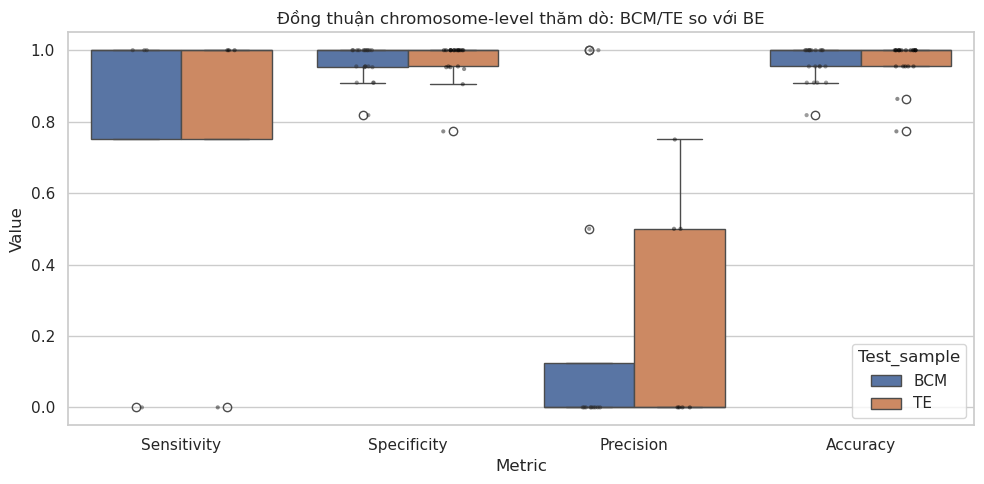

In [20]:
if len(agreement):
    metric_long = agreement.melt(
        id_vars=["Embryo_ID", "Test_sample"],
        value_vars=["Sensitivity", "Specificity", "Precision", "Accuracy"],
        var_name="Metric", value_name="Value",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=metric_long, x="Metric", y="Value", hue="Test_sample")
    sns.stripplot(
        data=metric_long, x="Metric", y="Value", hue="Test_sample",
        dodge=True, color="black", alpha=.45, size=3, legend=False,
    )
    plt.ylim(-.05, 1.05)
    plt.title("Đồng thuận chromosome-level thăm dò: BCM/TE so với BE")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "07_exploratory_chromosome_agreement.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Chưa đủ bộ ba CNR để tính đồng thuận chromosome-level.")

## 10. Đối chiếu đủ 63 mẫu với nhãn PGT-A công bố

Mỗi nhãn được ghép bằng `Embryo_ID + Sample_type`. Một mẫu được dự đoán aneuploid khi có ít nhất một CBS call LOSS/GAIN dài từ 4 Mb trên chr1–22 hoặc chrX.

Đối chiếu sự kiện ở đây chỉ xét **chromosome + chiều gain/loss**. `Chrom_direction_exact_match` yêu cầu tập sự kiện dự đoán và công bố khớp nhau ở mức này; chưa chấm overlap breakpoint hoặc cytoband arm. Muốn chấm event-level chính xác cần ánh xạ cytoband hg19 thành tọa độ.

Giới tính XX/XY lấy từ nhãn công bố chỉ để đặt copy number trung tính cho chrX. Đây là thông tin tham chiếu được dùng trong bước call và phải được công bố rõ khi báo cáo baseline.


In [21]:
published_labels = pd.read_csv(LABEL_CSV)
label_key = ["Embryo_ID", "Sample_type"]

if published_labels.duplicated(label_key).any():
    raise ValueError("Nhãn bị trùng Embryo_ID + Sample_type")
if len(published_labels) != 63:
    raise ValueError(f"Cần 63 nhãn, hiện có {len(published_labels)}")
if published_labels["Embryo_ID"].nunique() != 21:
    raise ValueError("Bảng nhãn phải có đúng 21 phôi")

labels_with_runs = metadata[["Run", "Embryo_ID", "Sample_type"]].merge(
    published_labels, on=label_key, how="left", validate="one_to_one"
)
if labels_with_runs["Published_PGTA"].isna().any():
    display(labels_with_runs[labels_with_runs["Published_PGTA"].isna()])
    raise ValueError("Có run chưa ghép được nhãn PGT-A")

labels_with_runs.to_csv(RESULTS_DIR / "published_labels_with_runs.csv", index=False)
print(f"PASS: {len(labels_with_runs)} run, {labels_with_runs['Embryo_ID'].nunique()} phôi, không thiếu nhãn.")
display(labels_with_runs.query("Embryo_ID == 'NK12'"))



PASS: 63 run, 21 phôi, không thiếu nhãn.


,Run,Embryo_ID,Sample_type,Published_PGTA,Published_class,Reference_role,Source_table
1,SRR8655357,NK12,BCM,"46,XX",euploid,test_sample,"Jiao et al. 2019, Table II"
3,SRR8655359,NK12,TE,"-Xq(q13.3->qter,~80 Mb),XX",aneuploid,test_sample,"Jiao et al. 2019, Table II"
4,SRR8655360,NK12,BE,"46,XX",euploid,BE_reference,"Jiao et al. 2019, Table II"


In [22]:
# Gọi copy number tuyệt đối từ 63 CBS CNS; dùng giới tính PGT-A để xử lý chrX đúng.
RUN_CNVKIT_CALL = True
CALL_DIR = CNVKIT_DIR / 'calls_cbs'
CALL_DIR.mkdir(parents=True, exist_ok=True)

def sex_from_pgta(label):
    text = str(label).upper()
    if 'XX' in text:
        return 'female'
    if 'XY' in text:
        return 'male'
    return None

def valid_call_file(path):
    return path.is_file() and path.stat().st_size > 0

call_inputs = cnv_files.loc[cnv_files['CNS_exists']].merge(
    labels_with_runs[['Run', 'Published_PGTA']],
    on='Run', how='inner', validate='one_to_one',
)
call_inputs['Sample_sex'] = call_inputs['Published_PGTA'].apply(sex_from_pgta)

if len(call_inputs) != 63:
    raise RuntimeError(f'Cần 63 CNS có nhãn PGT-A; hiện có {len(call_inputs)}')
if call_inputs['Sample_sex'].isna().any():
    unresolved = call_inputs.loc[call_inputs['Sample_sex'].isna(), 'Run'].tolist()
    raise ValueError(f'Không xác định được giới tính XX/XY cho: {unresolved}')

call_rows = []
for row in call_inputs.itertuples(index=False):
    output_call = CALL_DIR / f'{row.Run}.cbs.call.cns'
    if RUN_CNVKIT_CALL and not valid_call_file(output_call):
        command = [
            'cnvkit.py', 'call', str(row.CNS),
            '--method', 'threshold', '--ploidy', '2',
            '--sample-sex', row.Sample_sex,
            '-o', str(output_call),
        ]
        subprocess.run(command, check=True)
    call_rows.append({
        'Run': row.Run,
        'Sample_sex': row.Sample_sex,
        'Call_CNS': output_call,
        'Call_exists': valid_call_file(output_call),
    })

call_manifest = pd.DataFrame(call_rows)
n_calls = int(call_manifest['Call_exists'].sum())
print(f'CBS call CNS: {n_calls}/{len(call_manifest)}')
if len(call_manifest) != 63 or n_calls != 63:
    missing_calls = call_manifest.loc[~call_manifest['Call_exists'], 'Run'].tolist()
    display(call_manifest)
    raise RuntimeError(f'Cần đủ 63 CBS call CNS; còn thiếu: {missing_calls}')

print('PASS: đủ 63 CBS call CNS có hiệu chỉnh giới tính.')
display(call_manifest)


CBS call CNS: 63/63
PASS: đủ 63 CBS call CNS có hiệu chỉnh giới tính.


,Run,Sample_sex,Call_CNS,Call_exists
0,SRR8655356,male,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
1,SRR8655357,female,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
2,SRR8655358,male,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
3,SRR8655359,female,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
4,SRR8655360,female,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
...,...,...,...,...
58,SRR8655414,female,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
59,SRR8655415,male,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
60,SRR8655416,male,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True
61,SRR8655417,male,/home/vinhvu/genomeCNV/204206/cnvkit_500kb/cal...,True


In [23]:
MIN_EVENT_SIZE = 4_000_000

def normalize_chromosome(value):
    value = str(value)
    return value if value.startswith("chr") else f"chr{value}"

def parse_published_events(label):
    events = []
    for sign, chrom, arm in re.findall(r"([+-])(\d+|X|Y)([pq]?)", str(label)):
        events.append({
            "direction": "GAIN" if sign == "+" else "LOSS",
            "chromosome": f"chr{chrom}",
            "arm": arm or "whole",
        })
    return events

def called_abnormal_segments(call_path, sample_sex):
    calls = pd.read_csv(call_path, sep="	").copy()
    if "cn" not in calls.columns:
        raise KeyError(f"File call thiếu cột cn: {call_path}")
    calls["chromosome"] = calls["chromosome"].map(normalize_chromosome)
    calls["size"] = calls["end"] - calls["start"]
    def neutral_cn(chrom):
        if chrom == "chrX":
            return 2 if sample_sex == "female" else 1
        if chrom == "chrY":
            return 0 if sample_sex == "female" else 1
        return 2
    calls["neutral_cn"] = calls["chromosome"].map(neutral_cn)
    calls["direction"] = np.where(
        calls["cn"] < calls["neutral_cn"], "LOSS",
        np.where(calls["cn"] > calls["neutral_cn"], "GAIN", "NEUTRAL"),
    )
    return calls[
        (calls["size"] >= MIN_EVENT_SIZE)
        & calls["direction"].isin(["GAIN", "LOSS"])
        & (calls["chromosome"] != "chrY")
    ]

label_test_rows = []
testable = labels_with_runs.merge(
    call_manifest, on="Run", how="inner", validate="one_to_one"
)
testable = testable[testable["Call_exists"]].copy()

for row in testable.itertuples(index=False):
    expected = parse_published_events(row.Published_PGTA)
    observed = called_abnormal_segments(row.Call_CNS, row.Sample_sex)
    expected_keys = {
        (event['direction'], event['chromosome']) for event in expected
    }
    observed_keys = {
        (segment.direction, segment.chromosome)
        for segment in observed.itertuples(index=False)
    }
    detected_count = len(expected_keys & observed_keys)
    event_recall = (
        detected_count / len(expected_keys) if expected_keys else np.nan
    )
    predicted_class = 'aneuploid' if observed_keys else 'euploid'
    published_class = str(row.Published_class).strip().lower()
    class_match = predicted_class == published_class
    chrom_direction_exact_match = expected_keys == observed_keys
    observed_text = "; ".join(
        f"{'+' if r.direction == 'GAIN' else '-'}{r.chromosome.replace('chr', '')}:"
        f"{r.start}-{r.end}:cn={int(r.cn)}:log2={r.log2:.3f}"
        for r in observed.itertuples(index=False)
    ) or "none"
    label_test_rows.append({
        "Run": row.Run, "Embryo_ID": row.Embryo_ID,
        "Sample_type": row.Sample_type, "Published_PGTA": row.Published_PGTA,
        "Published_class": row.Published_class,
        'Expected_events': len(expected_keys),
        'Predicted_class': predicted_class,
        'Class_match': class_match,
        'Predicted_events': observed_text,
        'Expected_events_detected': detected_count,
        'Expected_event_recall': event_recall,
        'Chrom_direction_exact_match': chrom_direction_exact_match,
    })

published_label_test = pd.DataFrame(label_test_rows)
published_label_test.to_csv(RESULTS_DIR / 'published_label_test.tsv', sep='	', index=False)

if len(published_label_test) != 63:
    raise RuntimeError(f'Cần đánh giá đủ 63 mẫu với nhãn PGT-A; hiện có {len(published_label_test)}')

def binary_classification_metrics(frame, sample_type):
    truth = frame['Published_class'].astype(str).str.lower().eq('aneuploid')
    pred = frame['Predicted_class'].astype(str).str.lower().eq('aneuploid')
    tp = int((truth & pred).sum())
    tn = int((~truth & ~pred).sum())
    fp = int((~truth & pred).sum())
    fn = int((truth & ~pred).sum())
    sensitivity = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan
    precision = tp / (tp + fp) if tp + fp else np.nan
    npv = tn / (tn + fn) if tn + fn else np.nan
    accuracy = (tp + tn) / len(frame) if len(frame) else np.nan
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    f1 = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan
    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / denom if denom else np.nan
    return {
        'Sample_type': sample_type, 'N': len(frame),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Sensitivity_recall': sensitivity, 'Specificity': specificity,
        'Precision_PPV': precision, 'NPV': npv, 'Accuracy': accuracy,
        'Balanced_accuracy': balanced_accuracy, 'F1': f1, 'MCC': mcc,
    }

class_metric_rows = [
    binary_classification_metrics(group, sample_type)
    for sample_type, group in published_label_test.groupby('Sample_type')
]
class_metric_rows.append(binary_classification_metrics(published_label_test, 'ALL'))
published_class_metrics = pd.DataFrame(class_metric_rows)
published_class_metrics.to_csv(
    RESULTS_DIR / 'published_class_metrics.tsv', sep='	', index=False
)

print(f'Đã test đủ {len(published_label_test)} mẫu có CNS.')
display(published_label_test)
display(published_class_metrics.round(4))

Đã test đủ 63 mẫu có CNS.


,Run,Embryo_ID,Sample_type,Published_PGTA,Published_class,Expected_events,Predicted_class,Class_match,Predicted_events,Expected_events_detected,Expected_event_recall,Chrom_direction_exact_match
0,SRR8655356,NK5,BCM,"-15q(q14->q25.3,~53 Mb),XY",aneuploid,1,aneuploid,True,-1:142535434-150008875:cn=0:log2=-1.836; -5:49...,1,1.0,False
1,SRR8655357,NK12,BCM,"46,XX",euploid,0,aneuploid,False,-1:142535434-249240621:cn=1:log2=-0.320; -5:49...,0,NaN,False
2,SRR8655358,NK14,TE,"46,XY",euploid,0,aneuploid,False,-1:142535434-150008875:cn=0:log2=-1.173; -5:49...,0,NaN,False
3,SRR8655359,NK12,TE,"-Xq(q13.3->qter,~80 Mb),XX",aneuploid,1,aneuploid,True,-1:142535434-150008875:cn=1:log2=-1.034; -5:49...,1,1.0,False
4,SRR8655360,NK12,BE,"46,XX",euploid,0,aneuploid,False,-1:142535434-150008875:cn=0:log2=-1.333; -6:28...,0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...
58,SRR8655414,NK18,TE,"46,XX",euploid,0,aneuploid,False,-1:142535434-148954460:cn=0:log2=-1.565; -5:49...,0,NaN,False
59,SRR8655415,NK16,BCM,"46,XY",euploid,0,aneuploid,False,-1:142535434-148954460:cn=0:log2=-2.180; -5:49...,0,NaN,False
60,SRR8655416,NK16,BE,"46,XY",euploid,0,aneuploid,False,-1:142535434-150008875:cn=0:log2=-1.222; -9:39...,0,NaN,False
61,SRR8655417,NK16,TE,"46,XY",euploid,0,aneuploid,False,-1:142535434-148954460:cn=0:log2=-1.625; -9:39...,0,NaN,False


,Sample_type,N,TP,TN,FP,FN,Sensitivity_recall,Specificity,Precision_PPV,NPV,Accuracy,Balanced_accuracy,F1,MCC
0,BCM,21,8,0,13,0,1.0,0.0,0.3810,NaN,0.3810,0.5,0.5517,NaN
1,BE,21,6,0,15,0,1.0,0.0,0.2857,NaN,0.2857,0.5,0.4444,NaN
2,TE,21,9,0,12,0,1.0,0.0,0.4286,NaN,0.4286,0.5,0.6000,NaN
3,ALL,63,23,0,40,0,1.0,0.0,0.3651,NaN,0.3651,0.5,0.5349,NaN


## 11. Đánh giá bin-level tương thích với PRJNA720213

Cell tiếp theo chiếu copy-number state từ CBS call xuống lưới bin CNR chung của từng bộ ba. So sánh BCM–BE và TE–BE trên chr1–22 và chrX; chrY bị loại vì bin thưa và phụ thuộc giới tính.

Các nhóm metric được báo cáo:

- **Nhị phân CNV/neutral:** TP, TN, FP, FN, sensitivity/recall, specificity, precision/PPV, NPV, binary accuracy, balanced accuracy, F1, IoU/Jaccard và MCC.
- **Ba trạng thái LOSS/NEUTRAL/GAIN:** exact agreement, Cohen's kappa, F1 riêng cho LOSS, NEUTRAL và GAIN, cùng macro state F1.
- **Độ dài vùng:** bp-weighted agreement.
- **Mức tổng hợp:** từng phôi, pooled toàn bộ bin và phân phối mean/median/std giữa 21 phôi cho BCM và TE.

Đây là **đồng thuận nội bộ với BE**, không phải accuracy so với ground truth lâm sàng. Accuracy và agreement có thể cao vì phần lớn bin là neutral; vì vậy kết luận chính cần ưu tiên balanced accuracy, CNV F1, MCC, IoU và F1 theo trạng thái.


In [24]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR_BIN = Path('/home/vinhvu/genomeCNV/204206')
METADATA_BIN = PROJECT_DIR_BIN / 'metadata/SraRunTable.csv'
LABELS_BIN = PROJECT_DIR_BIN / 'metadata/PGTA_labels_PRJNA524206.csv'
CNVKIT_BIN = PROJECT_DIR_BIN / "cnvkit_500kb"
CALL_BIN = CNVKIT_BIN / "calls_cbs"
RESULTS_BIN = PROJECT_DIR_BIN / 'eda_results'
RESULTS_BIN.mkdir(parents=True, exist_ok=True)
BIN_CHROMS = [f'chr{i}' for i in range(1, 23)] + ['chrX']

def classify_tissue_bin(value):
    text = str(value).lower()
    if 'culture medium' in text or re.search(r'\bbcm\b', text):
        return 'BCM'
    if 'trophectoderm' in text or re.search(r'\bte\b', text):
        return 'TE'
    if 'blastocyst-stage embryo' in text or re.search(r'\bbe\b', text):
        return 'BE'
    return 'UNKNOWN'

def normalize_chromosome_bin(value):
    value = str(value)
    return value if value.startswith('chr') else f'chr{value}'

def sex_from_label_bin(label):
    text = str(label).upper()
    if 'XX' in text:
        return 'female'
    if 'XY' in text:
        return 'male'
    return None

metadata_bin = pd.read_csv(METADATA_BIN)
metadata_bin = metadata_bin[['Run', 'isolate', 'tissue']].copy()
metadata_bin['Embryo_ID'] = metadata_bin['isolate'].astype(str).str.strip()
metadata_bin['Sample_type'] = metadata_bin['tissue'].apply(classify_tissue_bin)
labels_bin = pd.read_csv(LABELS_BIN)[['Embryo_ID', 'Sample_type', 'Published_PGTA']]
manifest_bin = metadata_bin.merge(labels_bin, on=['Embryo_ID', 'Sample_type'], how='left', validate='one_to_one')
manifest_bin['Sample_sex'] = manifest_bin['Published_PGTA'].apply(sex_from_label_bin)
if len(manifest_bin) != 63 or manifest_bin['Sample_sex'].isna().any():
    raise ValueError('Manifest bin-level phải có 63 run và giới tính XX/XY cho mọi mẫu')

def locate_cnr_bin(run):
    exact = CNVKIT_BIN / f'{run}.filtered.sorted.cnr'
    return exact if exact.is_file() and exact.stat().st_size > 0 else None

def bin_states_from_cbs_call(run, sample_sex):
    cnr_path = locate_cnr_bin(run)
    call_path = CALL_BIN / f'{run}.cbs.call.cns'
    if cnr_path is None or not call_path.exists():
        return None
    cnr = pd.read_csv(cnr_path, sep='	')
    calls = pd.read_csv(call_path, sep='	')
    cnr['chromosome'] = cnr['chromosome'].map(normalize_chromosome_bin)
    calls['chromosome'] = calls['chromosome'].map(normalize_chromosome_bin)
    cnr = cnr[cnr['chromosome'].isin(BIN_CHROMS)].copy()
    cnr['midpoint'] = (cnr['start'].astype(np.int64) + cnr['end'].astype(np.int64)) // 2
    pieces = []
    for chrom, bins_chr in cnr.groupby('chromosome', sort=False):
        seg = calls[calls['chromosome'] == chrom].sort_values(['start', 'end']).copy()
        if seg.empty:
            continue
        starts = seg['start'].to_numpy(dtype=np.int64)
        ends = seg['end'].to_numpy(dtype=np.int64)
        cn = seg['cn'].to_numpy()
        mids = bins_chr['midpoint'].to_numpy(dtype=np.int64)
        idx = np.searchsorted(starts, mids, side='right') - 1
        valid = (idx >= 0)
        valid[valid] &= mids[valid] < ends[idx[valid]]
        assigned = bins_chr.loc[valid, ['chromosome', 'start', 'end']].copy()
        assigned['cn'] = cn[idx[valid]]
        pieces.append(assigned)
    if not pieces:
        return None
    states = pd.concat(pieces, ignore_index=True)
    neutral = np.where(states['chromosome'].eq('chrX'), 2 if sample_sex == 'female' else 1, 2)
    states['state'] = np.where(states['cn'] < neutral, 'LOSS', np.where(states['cn'] > neutral, 'GAIN', 'NEUTRAL'))
    states['bin_bp'] = states['end'] - states['start']
    if states.duplicated(['chromosome', 'start', 'end']).any():
        raise ValueError(f'{run}: duplicate bin coordinates after segment projection')
    return states[['chromosome', 'start', 'end', 'bin_bp', 'state']]

def safe_ratio_bin(num, den):
    return num / den if den else np.nan

def class_f1_bin(y_true, y_pred, label):
    tp = int(((y_true == label) & (y_pred == label)).sum())
    fp = int(((y_true != label) & (y_pred == label)).sum())
    fn = int(((y_true == label) & (y_pred != label)).sum())
    return safe_ratio_bin(2 * tp, 2 * tp + fp + fn)

def cohen_kappa_bin(y_true, y_pred):
    labels = ['LOSS', 'NEUTRAL', 'GAIN']
    n = len(y_true)
    if not n:
        return np.nan
    observed = np.mean(y_true.to_numpy() == y_pred.to_numpy())
    expected = sum(
        y_true.eq(label).mean() * y_pred.eq(label).mean()
        for label in labels
    )
    return (observed - expected) / (1 - expected) if expected < 1 else np.nan

def calculate_bin_metrics(frame, embryo_id, test_sample):
    truth_abn = frame['BE_state'].ne('NEUTRAL')
    pred_abn = frame['Test_state'].ne('NEUTRAL')
    tp = int((truth_abn & pred_abn).sum())
    tn = int((~truth_abn & ~pred_abn).sum())
    fp = int((~truth_abn & pred_abn).sum())
    fn = int((truth_abn & ~pred_abn).sum())
    exact = frame['BE_state'].eq(frame['Test_state'])
    sensitivity = safe_ratio_bin(tp, tp + fn)
    specificity = safe_ratio_bin(tn, tn + fp)
    precision = safe_ratio_bin(tp, tp + fp)
    npv = safe_ratio_bin(tn, tn + fn)
    binary_accuracy = safe_ratio_bin(tp + tn, len(frame))
    balanced_accuracy = (
        np.nanmean([sensitivity, specificity])
        if not (pd.isna(sensitivity) and pd.isna(specificity)) else np.nan
    )
    f1 = safe_ratio_bin(2 * tp, 2 * tp + fp + fn)
    iou = safe_ratio_bin(tp, tp + fp + fn)
    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / mcc_den if mcc_den else np.nan
    loss_f1 = class_f1_bin(frame['BE_state'], frame['Test_state'], 'LOSS')
    neutral_f1 = class_f1_bin(frame['BE_state'], frame['Test_state'], 'NEUTRAL')
    gain_f1 = class_f1_bin(frame['BE_state'], frame['Test_state'], 'GAIN')
    macro_state_f1 = np.nanmean([loss_f1, neutral_f1, gain_f1])
    return {
        'Embryo_ID': embryo_id,
        'Test_sample': test_sample,
        'N_shared_bins': int(len(frame)),
        'N_BE_CNV_bins': int(truth_abn.sum()),
        'N_test_CNV_bins': int(pred_abn.sum()),
        'Exact_state_agreement': exact.mean(),
        'Cohen_kappa_state': cohen_kappa_bin(frame['BE_state'], frame['Test_state']),
        'Bp_weighted_agreement': np.average(exact, weights=frame['bin_bp']),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision_PPV': precision,
        'NPV': npv,
        'Binary_accuracy': binary_accuracy,
        'Balanced_accuracy': balanced_accuracy,
        'CNV_F1': f1,
        'CNV_IoU': iou,
        'MCC': mcc,
        'Loss_F1': loss_f1,
        'Neutral_F1': neutral_f1,
        'Gain_F1': gain_f1,
        'Macro_state_F1': macro_state_f1,
    }

state_cache_bin = {}
for row in manifest_bin.itertuples(index=False):
    states = bin_states_from_cbs_call(row.Run, row.Sample_sex)
    if states is not None:
        state_cache_bin[row.Run] = states
if len(state_cache_bin) != 63:
    missing_states = sorted(set(manifest_bin['Run']) - set(state_cache_bin))
    raise RuntimeError(f'Cần 63 bộ bin state từ CNR + calls_cbs; còn thiếu: {missing_states}')

pairwise_frames_bin = []
metric_rows_bin = []
confusion_rows_bin = []
for embryo_id, trio in manifest_bin.groupby('Embryo_ID'):
    run_by_type = dict(zip(trio['Sample_type'], trio['Run']))
    if not all(run_by_type.get(t) in state_cache_bin for t in ['BCM', 'TE', 'BE']):
        continue
    be = state_cache_bin[run_by_type['BE']].rename(columns={'state': 'BE_state'})
    for test_sample in ['BCM', 'TE']:
        test = state_cache_bin[run_by_type[test_sample]].rename(columns={'state': 'Test_state'})
        paired = be.merge(test[['chromosome', 'start', 'end', 'Test_state']], on=['chromosome', 'start', 'end'], how='inner', validate='one_to_one')
        if paired.empty:
            continue
        paired['Embryo_ID'] = embryo_id
        paired['Test_sample'] = test_sample
        pairwise_frames_bin.append(paired)
        metric_rows_bin.append(calculate_bin_metrics(paired, embryo_id, test_sample))
        counts = paired.groupby(['BE_state', 'Test_state']).size().rename('N_bins').reset_index()
        counts.insert(0, 'Test_sample', test_sample)
        counts.insert(0, 'Embryo_ID', embryo_id)
        confusion_rows_bin.append(counts)

bin_level_by_embryo = pd.DataFrame(metric_rows_bin)
if not pairwise_frames_bin:
    raise RuntimeError('Chưa có bộ ba đủ CNR và CBS call để đánh giá bin-level')
if bin_level_by_embryo['Embryo_ID'].nunique() != 21 or len(bin_level_by_embryo) != 42:
    raise RuntimeError(
        f'Cần 21 phôi và 42 phép so sánh; hiện có '
        f"{bin_level_by_embryo['Embryo_ID'].nunique()} phôi, {len(bin_level_by_embryo)} dòng"
    )
bin_pairs_all = pd.concat(pairwise_frames_bin, ignore_index=True)
bin_level_summary_rows = []
for test_sample, frame in bin_pairs_all.groupby('Test_sample'):
    bin_level_summary_rows.append(calculate_bin_metrics(frame, 'POOLED', test_sample))
bin_level_summary = pd.DataFrame(bin_level_summary_rows)
bin_level_confusion = pd.concat(confusion_rows_bin, ignore_index=True)

report_metrics = [
    'Exact_state_agreement', 'Cohen_kappa_state', 'Bp_weighted_agreement',
    'Sensitivity', 'Specificity', 'Precision_PPV', 'NPV',
    'Binary_accuracy', 'Balanced_accuracy', 'CNV_F1', 'CNV_IoU', 'MCC',
    'Loss_F1', 'Neutral_F1', 'Gain_F1', 'Macro_state_F1',
]
bin_level_distribution = (
    bin_level_by_embryo.groupby('Test_sample')[report_metrics]
    .agg(['count', 'mean', 'median', 'std'])
    .reset_index()
)
bin_level_distribution.columns = [
    col[0] if col[1] == '' else f'{col[0]}_{col[1]}'
    for col in bin_level_distribution.columns
]

by_embryo_path = RESULTS_BIN / 'bin_level_pairwise_by_embryo.tsv'
summary_path = RESULTS_BIN / 'bin_level_pairwise_summary.tsv'
distribution_path = RESULTS_BIN / 'bin_level_metric_distribution.tsv'
confusion_path = RESULTS_BIN / 'bin_level_state_confusion.tsv'
bin_level_by_embryo.to_csv(by_embryo_path, sep='	', index=False)
bin_level_summary.to_csv(summary_path, sep='	', index=False)
bin_level_distribution.to_csv(distribution_path, sep='	', index=False)
bin_level_confusion.to_csv(confusion_path, sep='	', index=False)

metric_columns = [
    'Embryo_ID', 'Test_sample', 'N_shared_bins',
    'N_BE_CNV_bins', 'N_test_CNV_bins',
    'Exact_state_agreement', 'Cohen_kappa_state',
    'Sensitivity', 'Specificity', 'Precision_PPV',
    'Balanced_accuracy', 'CNV_F1', 'CNV_IoU', 'MCC',
    'Loss_F1', 'Gain_F1', 'Macro_state_F1',
]
print(f'Đã đánh giá {bin_level_by_embryo.Embryo_ID.nunique()} phôi; phạm vi chr1–22,X; CBS call chiếu xuống bin.')
display(bin_level_by_embryo[metric_columns].round(4))
display(bin_level_summary[metric_columns].round(4))
display(bin_level_distribution.round(4))
print(
    'Đã xuất:', by_embryo_path.name, summary_path.name,
    distribution_path.name, confusion_path.name,
)

Đã đánh giá 21 phôi; phạm vi chr1–22,X; CBS call chiếu xuống bin.


,Embryo_ID,Test_sample,N_shared_bins,N_BE_CNV_bins,N_test_CNV_bins,Exact_state_agreement,Cohen_kappa_state,Sensitivity,Specificity,Precision_PPV,Balanced_accuracy,CNV_F1,CNV_IoU,MCC,Loss_F1,Gain_F1,Macro_state_F1
0,NK1,BCM,5720,643,763,0.9731,0.8786,0.9736,0.9730,0.8204,0.9733,0.8905,0.8026,0.8794,0.8493,1.0000,0.9447
1,NK1,TE,5721,643,1162,0.9086,0.6714,0.9969,0.8974,0.5516,0.9471,0.7102,0.5507,0.7021,0.6319,1.0000,0.8592
2,NK10,BCM,5720,124,321,0.9407,0.2196,0.4274,0.9521,0.1651,0.6898,0.2382,0.1352,0.2402,0.3630,0.0000,0.4441
3,NK10,TE,5719,124,63,0.9858,0.5604,0.4274,0.9982,0.8413,0.7128,0.5668,0.3955,0.5939,0.5668,NaN,0.7798
4,NK11,BCM,5718,55,148,0.9823,0.4954,0.9273,0.9829,0.3446,0.9551,0.5025,0.3355,0.5594,0.5025,NaN,0.7467
5,NK11,TE,5718,55,60,0.9942,0.7101,0.7455,0.9966,0.6833,0.8710,0.7130,0.5541,0.7108,0.7130,NaN,0.8551
6,NK12,BCM,5717,66,427,0.9365,0.2502,0.9848,0.9359,0.1522,0.9604,0.2637,0.1519,0.3742,0.3210,0.0000,0.4293
7,NK12,TE,5717,66,246,0.9615,0.2818,0.6970,0.9646,0.1870,0.8308,0.2949,0.1729,0.3483,0.2949,NaN,0.6375
8,NK13,BCM,5721,139,280,0.9708,0.5915,0.9065,0.9724,0.4500,0.9394,0.6014,0.4300,0.6272,0.4621,0.9147,0.7872
9,NK13,TE,5721,139,701,0.8993,0.2928,0.9496,0.8981,0.1883,0.9239,0.3143,0.1864,0.3980,0.1771,1.0000,0.7076


,Embryo_ID,Test_sample,N_shared_bins,N_BE_CNV_bins,N_test_CNV_bins,Exact_state_agreement,Cohen_kappa_state,Sensitivity,Specificity,Precision_PPV,Balanced_accuracy,CNV_F1,CNV_IoU,MCC,Loss_F1,Gain_F1,Macro_state_F1
0,POOLED,BCM,120111,3662,11298,0.9204,0.3347,0.7463,0.9264,0.2419,0.8364,0.3654,0.2235,0.3962,0.4024,0.1922,0.5175
1,POOLED,TE,120105,3661,6361,0.9580,0.4793,0.6796,0.9667,0.3911,0.8232,0.4965,0.3302,0.4961,0.5243,0.3817,0.6280


,Test_sample,Exact_state_agreement_count,Exact_state_agreement_mean,Exact_state_agreement_median,Exact_state_agreement_std,Cohen_kappa_state_count,Cohen_kappa_state_mean,Cohen_kappa_state_median,Cohen_kappa_state_std,Bp_weighted_agreement_count,Bp_weighted_agreement_mean,Bp_weighted_agreement_median,Bp_weighted_agreement_std,Sensitivity_count,Sensitivity_mean,Sensitivity_median,Sensitivity_std,Specificity_count,Specificity_mean,Specificity_median,Specificity_std,Precision_PPV_count,Precision_PPV_mean,Precision_PPV_median,Precision_PPV_std,NPV_count,NPV_mean,NPV_median,NPV_std,Binary_accuracy_count,Binary_accuracy_mean,Binary_accuracy_median,Binary_accuracy_std,Balanced_accuracy_count,Balanced_accuracy_mean,Balanced_accuracy_median,Balanced_accuracy_std,CNV_F1_count,CNV_F1_mean,CNV_F1_median,CNV_F1_std,CNV_IoU_count,CNV_IoU_mean,CNV_IoU_median,CNV_IoU_std,MCC_count,MCC_mean,MCC_median,MCC_std,Loss_F1_count,Loss_F1_mean,Loss_F1_median,Loss_F1_std,Neutral_F1_count,Neutral_F1_mean,Neutral_F1_median,Neutral_F1_std,Gain_F1_count,Gain_F1_mean,Gain_F1_median,Gain_F1_std,Macro_state_F1_count,Macro_state_F1_mean,Macro_state_F1_median,Macro_state_F1_std
0,BCM,21,0.9204,0.9407,0.0699,21,0.3804,0.3807,0.2492,21,0.9207,0.9408,0.0699,21,0.7855,0.9403,0.2782,21,0.9266,0.9462,0.0677,21,0.3149,0.2616,0.2548,21,0.9912,0.9986,0.0161,21,0.921,0.9407,0.0704,21,0.8560,0.9394,0.1548,21,0.4078,0.4143,0.2500,21,0.2888,0.2613,0.222,21,0.4417,0.4783,0.2513,21,0.4304,0.4621,0.2262,21,0.9566,0.9692,0.0409,13,0.2242,0.0000,0.4265,21,0.5977,0.5555,0.1840
1,TE,21,0.9580,0.9792,0.0601,21,0.5596,0.5604,0.2804,21,0.9585,0.9790,0.0603,21,0.6794,0.6970,0.2524,21,0.9662,0.9921,0.0559,21,0.5847,0.6329,0.3371,21,0.9894,0.9962,0.0165,21,0.958,0.9792,0.0601,21,0.8228,0.8482,0.1342,21,0.5740,0.5668,0.2675,21,0.4493,0.3955,0.266,21,0.5837,0.6092,0.2716,21,0.5848,0.5734,0.2470,21,0.9770,0.9894,0.0342,8,0.4981,0.4924,0.5325,21,0.7533,0.7798,0.1854


Đã xuất: bin_level_pairwise_by_embryo.tsv bin_level_pairwise_summary.tsv bin_level_metric_distribution.tsv bin_level_state_confusion.tsv


## 12. Checklist kết thúc EDA

EDA đạt khi:

- Metadata không có UNKNOWN/trùng Run và xác nhận số bộ ba.
- Toàn bộ BAM vượt `samtools quickcheck`, có index, QC được tổng hợp bằng MultiQC.
- Tất cả CNR/CNS dùng cùng hg19, flat reference và bin 500 kb.
- Autosomal median gần 0; MAD/IQR được báo cáo và các outlier được kiểm tra.
- Có profile từng run, profile bộ ba và heatmap chromosome-level.
- Đủ 63 nhãn PGT-A và ghép theo `Embryo_ID + Sample_type`, không theo thứ tự dòng.
- Bin-level báo cáo cả state agreement và CNV F1; không diễn giải agreement bị chi phối bởi bin trung tính thành accuracy lâm sàng.
- CNVkit+CBS+call là baseline kỹ thuật dùng để tạo và đánh giá trạng thái CNV.


In [25]:
excluded_output_prefixes = (
    'downstream_classifier_',
    'model_baseline_',
    '08_downstream_classifier_',
    '08_model_baseline_',
)
outputs = sorted(
    path.relative_to(PROJECT_DIR)
    for path in RESULTS_DIR.rglob('*')
    if path.is_file()
    and not path.name.startswith(excluded_output_prefixes)
)
print('Các đầu ra EDA đã tạo:')
for path in outputs:
    print(' -', path)


Các đầu ra đã tạo:
 - eda_results/alignment_qc_summary.csv
 - eda_results/all_genomewide_profiles.pdf
 - eda_results/bin_level_metric_distribution.tsv
 - eda_results/bin_level_pairwise_by_embryo.tsv
 - eda_results/bin_level_pairwise_summary.tsv
 - eda_results/bin_level_state_confusion.tsv
 - eda_results/chromosome_median_log2.tsv
 - eda_results/cnv_signal_qc.csv
 - eda_results/exploratory_baseline_metrics.tsv
 - eda_results/exploratory_chromosome_agreement.tsv
 - eda_results/figures/01_metadata_overview.png
 - eda_results/figures/02_alignment_qc.png
 - eda_results/figures/03_cnv_signal_qc.png
 - eda_results/figures/04_profile_SRR8655356.png
 - eda_results/figures/04_profile_SRR8655357.png
 - eda_results/figures/05_trio_profile_NK1.png
 - eda_results/figures/05_trio_profile_NK12.png
 - eda_results/figures/06_chromosome_heatmap.png
 - eda_results/figures/07_exploratory_baseline_metrics.png
 - eda_results/figures/07_exploratory_chromosome_agreement.png
 - eda_results/file_manifest.csv
 - 